# UAV Vehicle Detection — Colab Training

Detects **car · bus · truck** from aerial drone imagery using YOLOv5s  
Dataset: 7,595 images hosted on Roboflow | DRDO-DEAL Internship

---

### Before running
1. `Runtime → Change runtime type → T4 GPU → Save`
2. `Runtime → Run all`

Everything is automated. Training takes ~2–3 hours on a T4 GPU.  
Weights and results are saved to **Google Drive → UAV_CNN/results/** continuously.

## Step 1 — Verify GPU

In [1]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError('No GPU detected. Go to Runtime → Change runtime type → T4 GPU → Save, then reconnect.')

print(f'GPU  : {torch.cuda.get_device_name(0)}')
print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print('GPU ready ✓')

GPU  : Tesla T4
VRAM : 15.6 GB
GPU ready ✓


## Step 2 — Mount Google Drive

Drive is mounted first so all outputs are saved continuously during training.  
If the Colab session crashes, weights up to the last saved epoch are in Drive.

In [2]:
import os
from google.colab import drive

drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/UAV_CNN/results'
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f'Drive mounted. Results → {DRIVE_DIR}')

Mounted at /content/drive
Drive mounted. Results → /content/drive/MyDrive/UAV_CNN/results


## Step 3 — Clone YOLOv5 and install dependencies

In [3]:
import subprocess, sys
from pathlib import Path

if not Path('/content/yolov5').exists():
    subprocess.run(['git', 'clone', '--quiet',
                    'https://github.com/ultralytics/yolov5', '/content/yolov5'], check=True)
    print('YOLOv5 cloned.')
else:
    print('YOLOv5 already present.')

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'setuptools'], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-qr', '/content/yolov5/requirements.txt'], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'roboflow'], check=True)
print('All dependencies installed ✓')

YOLOv5 cloned.
All dependencies installed ✓


## Step 4 — Download dataset from Roboflow

7,595 images (train / val / test) in YOLOv5 format.

In [ ]:
import glob, shutil, getpass
from roboflow import Roboflow

# Paste your Roboflow Private API key when prompted (it is NOT stored in the notebook).
# Get it from: Roboflow -> Settings -> Roboflow API -> Private API Key
ROBOFLOW_API_KEY = os.environ.get('ROBOFLOW_API_KEY') or getpass.getpass('Roboflow Private API key: ')

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace('drdo-pylxb').project('uav-vehicle-detection-9t43s')
version = project.version(1)
dataset = version.download('yolov5')

DATASET_DIR = dataset.location
print(f'\nDataset location: {DATASET_DIR}')

for split in ['train', 'valid', 'test']:
    p = os.path.join(DATASET_DIR, split, 'images')
    if os.path.exists(p):
        n = len([f for f in os.listdir(p) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f'  {split:>6}: {n} images')

## Step 5 — Configure YAML and hyperparameters

In [5]:
import yaml

# ── Find the YAML Roboflow generated ─────────────────────────────────
yaml_files = glob.glob(os.path.join(DATASET_DIR, '*.yaml'))
if not yaml_files:
    raise FileNotFoundError(f'No YAML in {DATASET_DIR} — did Step 4 finish?')
DATA_YAML = yaml_files[0]

with open(DATA_YAML) as f:
    data_cfg = yaml.safe_load(f)

# ── Detect actual image folders (Roboflow uses 'valid', YOLOv5 needs 'val') ──
def find_images(base, *candidates):
    for name in candidates:
        p = os.path.join(base, name, 'images')
        if os.path.exists(p):
            return p
    return None

train_dir = find_images(DATASET_DIR, 'train')
val_dir   = find_images(DATASET_DIR, 'valid', 'val')
test_dir  = find_images(DATASET_DIR, 'test')

if not train_dir:
    raise FileNotFoundError(f'No train/images folder found under {DATASET_DIR}')
if not val_dir:
    raise FileNotFoundError(f'No valid/images or val/images folder found under {DATASET_DIR}')

# ── Rewrite YAML with absolute paths — eliminates all path ambiguity ──
data_cfg['path']  = DATASET_DIR
data_cfg['train'] = train_dir   # absolute path
data_cfg['val']   = val_dir     # absolute path
data_cfg.pop('valid', None)     # remove old 'valid' key if present
if test_dir:
    data_cfg['test'] = test_dir
else:
    data_cfg.pop('test', None)

with open(DATA_YAML, 'w') as f:
    yaml.dump(data_cfg, f)

# ── Verify + print what YOLOv5 will see ──────────────────────────────
print(f'Data YAML : {DATA_YAML}')
print(f'Classes   : {data_cfg["names"]}')
print()
for split, path in [('train', train_dir), ('val', val_dir), ('test', test_dir)]:
    if path:
        n = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f'  {split:>6}: {n} images  ({path})')

# ── Write aerial-optimised hyperparameters ────────────────────────────
hyp = {
    'lr0': 0.01, 'lrf': 0.01, 'momentum': 0.937, 'weight_decay': 0.0005,
    'warmup_epochs': 3.0, 'warmup_momentum': 0.8, 'warmup_bias_lr': 0.1,
    'box': 0.05, 'cls': 0.5, 'cls_pw': 1.0,
    'obj': 1.0, 'obj_pw': 1.0, 'iou_t': 0.2, 'anchor_t': 4.0, 'fl_gamma': 0.0,
    'hsv_h': 0.015, 'hsv_s': 0.5, 'hsv_v': 0.4,
    'degrees': 15.0, 'translate': 0.1, 'scale': 0.6,
    'shear': 0.0, 'perspective': 0.0,
    'flipud': 0.5, 'fliplr': 0.5,
    'mosaic': 1.0, 'mixup': 0.1, 'copy_paste': 0.0
}
HYP_PATH = '/content/yolov5/hyp_uav.yaml'
with open(HYP_PATH, 'w') as f:
    yaml.dump(hyp, f)
print(f'\nHyp YAML  : {HYP_PATH} ✓')
print('\nYAML written — ready to train.')

Data YAML : /content/uav-vehicle-detection-1/data.yaml
Classes   : ['bus', 'car', 'truck']

   train: 2097 images  (/content/uav-vehicle-detection-1/train/images)
     val: 841 images  (/content/uav-vehicle-detection-1/valid/images)
    test: 857 images  (/content/uav-vehicle-detection-1/test/images)

Hyp YAML  : /content/yolov5/hyp_uav.yaml ✓

YAML written — ready to train.


## Step 6 — Train

| Setting | Value |
|---|---|
| Model | YOLOv5s (~7.2 M params) |
| Epochs | 100 (early stop at patience=50) |
| Batch size | 16 (safe for T4 4 GB VRAM) |
| Image size | 640 × 640 px |

> If you see **CUDA out-of-memory**, change `BATCH` to `8` below.

In [6]:
import re
from tqdm.auto import tqdm

EPOCHS = 100
BATCH  = 16   # lower to 8 if CUDA out-of-memory

train_cmd = [
    sys.executable, '/content/yolov5/train.py',
    '--weights',    'yolov5s.pt',
    '--data',       DATA_YAML,
    '--hyp',        HYP_PATH,
    '--epochs',     str(EPOCHS),
    '--batch-size', str(BATCH),
    '--imgsz',      '640',
    '--project',    '/content/runs/train',
    '--name',       'uav_detector',
    '--patience',   '50',
    '--device',     '0',
    '--workers',    '2',
    '--exist-ok',
]

print('━' * 65)
print(f'  UAV Vehicle Detector — Training')
print(f'  YOLOv5s | Epochs: {EPOCHS} | Batch: {BATCH} | Img: 640 px')
print('━' * 65 + '\n')

epoch_bar = tqdm(total=EPOCHS, desc='  Epochs', unit='ep', colour='green',
                 bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} {postfix}')

env = {**os.environ, 'PYTHONUNBUFFERED': '1'}
proc = subprocess.Popen(train_cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                        text=True, bufsize=1, cwd='/content/yolov5', env=env)

SHOW = [
    re.compile(r'^\s*\d+/\d+\s+[\d.]+G'),
    re.compile(r'^\s+all\s+\d+'),
    re.compile(r'^\s+(car|bus|truck)\s+\d+'),
    re.compile(r'Epoch\s+gpu_mem'),
    re.compile(r'Class\s+Images\s+Labels'),
    re.compile(r'(Early stopping|Results saved|best\.pt)', re.I),
]
epoch_re   = re.compile(r'^\s*(\d+)/\d+\s+[\d.]+G')
metrics_re = re.compile(r'^\s+all\s+(\d+)\s+(\d+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)')
error_re   = re.compile(r'(Traceback|RuntimeError|AssertionError|CUDA error|'
                        r'FileNotFoundError|Exception|Error:)', re.I)

current_epoch = -1
best_map50    = 0.0
output_buf    = []
in_error      = False

for raw in iter(proc.stdout.readline, ''):
    line = raw.rstrip()
    output_buf.append(line)

    if error_re.search(line):
        in_error = True

    m = epoch_re.match(line)
    if m:
        ep = int(m.group(1))
        if ep > current_epoch:
            epoch_bar.update(ep - current_epoch)
            current_epoch = ep

    is_new_best = False
    mm = metrics_re.match(line)
    if mm:
        p, r, map50, map595 = float(mm.group(3)), float(mm.group(4)), float(mm.group(5)), float(mm.group(6))
        if map50 > best_map50:
            best_map50 = map50
            is_new_best = True
        epoch_bar.set_postfix_str(f'mAP50={map50:.3f} best={best_map50:.3f}  P={p:.3f} R={r:.3f}')

    if in_error:
        tqdm.write(line)
    elif any(pat.search(line) for pat in SHOW):
        tqdm.write(line)
        if is_new_best:
            tqdm.write(f'  ★  New best mAP@0.5 = {best_map50:.4f}')

proc.wait()
epoch_bar.close()

if proc.returncode != 0:
    if not in_error:
        tqdm.write('\n=== Last 80 lines of output ===')
        for l in output_buf[-80:]:
            tqdm.write(l)
    raise RuntimeError(
        f'Training failed (exit {proc.returncode}).\n'
        'Fixes:\n'
        '  CUDA OOM      → set BATCH = 8 above\n'
        '  Dataset error → re-run Steps 4–5'
    )

print('\n' + '━' * 65)
print(f'  Training complete!   Best mAP@0.5 = {best_map50:.4f}')
print('━' * 65)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  UAV Vehicle Detector — Training
  YOLOv5s | Epochs: 100 | Batch: 16 | Img: 640 px
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



  Epochs:   0%|          | 0/100 

Streaming output truncated to the last 5000 lines.
      81/99      4.35G    0.03969    0.04553   0.003284        638        640:  26%|██▌       | 34/132 [00:13<00:38,  2.54it/s]
      81/99      4.35G    0.03969    0.04553   0.003284        638        640:  27%|██▋       | 35/132 [00:13<00:32,  2.95it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
      81/99      4.35G    0.03968    0.04566   0.003262        775        640:  27%|██▋       | 35/132 [00:14<00:32,  2.95it/s]
      81/99      4.35G    0.03968    0.04566   0.003262        775        640:  27%|██▋       | 36/132 [00:14<00:35,  2.73it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
      81/99      4.35G    0.03961    0.04555    0.00323        592        640:  27%|██▋       | 36/132 [00:14<00:35,  2.73it/s]
     

## Step 7 — Evaluate on validation set

In [7]:
run_dirs = sorted(glob.glob('/content/runs/train/uav_detector*'))
RUN_DIR = run_dirs[-1]
BEST_PT = os.path.join(RUN_DIR, 'weights', 'best.pt')
print(f'Run dir      : {RUN_DIR}')
print(f'Best weights : {BEST_PT}')

result = subprocess.run([
    sys.executable, '/content/yolov5/val.py',
    '--weights', BEST_PT,
    '--data',    DATA_YAML,
    '--imgsz',   '640',
    '--device',  '0',
    '--workers', '2',
    '--verbose',
], cwd='/content/yolov5', capture_output=True, text=True)

print(result.stdout[-3000:])
if result.returncode != 0:
    print('=== STDERR ==='); print(result.stderr[-2000:])

Run dir      : /content/runs/train/uav_detector
Best weights : /content/runs/train/uav_detector/weights/best.pt



## Step 8 — Training curves

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = glob.glob('/content/runs/train/**/results.csv', recursive=True)
if not csv_path:
    raise FileNotFoundError('results.csv not found — did training complete?')
csv_path = csv_path[0]

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Training Results — UAV Vehicle Detector (YOLOv5s)', fontsize=14)

plots = [
    ('train/box_loss',       'Box Loss',       axes[0, 0]),
    ('train/obj_loss',       'Objectness Loss', axes[0, 1]),
    ('train/cls_loss',       'Class Loss',      axes[0, 2]),
    ('metrics/mAP_0.5',      'mAP@0.5',         axes[1, 0]),
    ('metrics/mAP_0.5:0.95', 'mAP@0.5:0.95',    axes[1, 1]),
    ('metrics/precision',    'Precision',       axes[1, 2]),
]
for col, title, ax in plots:
    if col in df.columns:
        ax.plot(df['epoch'], df[col], linewidth=1.5)
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n========= FINAL METRICS =========')
print(f'mAP@0.5      : {df["metrics/mAP_0.5"].max():.4f}')
print(f'mAP@0.5:0.95 : {df["metrics/mAP_0.5:0.95"].max():.4f}')
print(f'Precision    : {df["metrics/precision"].max():.4f}')
print(f'Recall       : {df["metrics/recall"].max():.4f}')
print('=================================')

## Step 9 — Inference on sample test images

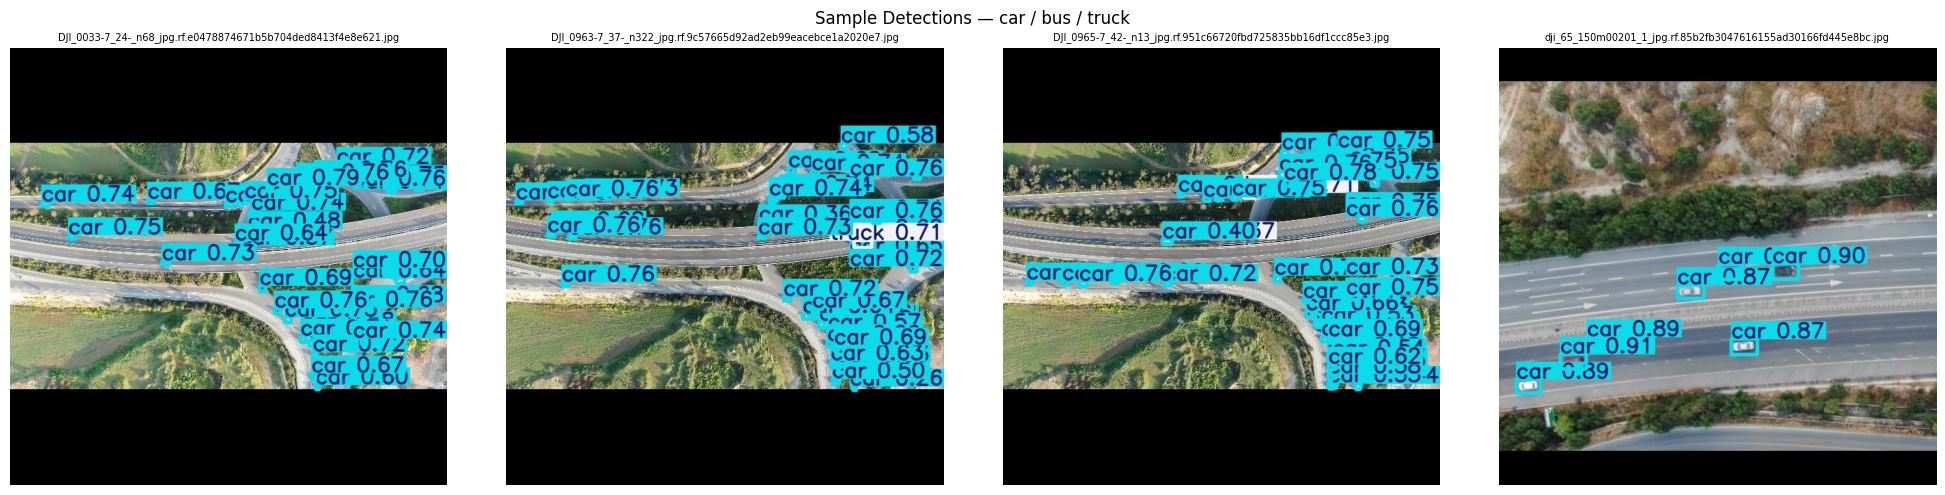

In [9]:
import random
import numpy as np
from PIL import Image

test_dir = os.path.join(DATASET_DIR, 'test', 'images')
if not os.path.exists(test_dir):
    test_dir = os.path.join(DATASET_DIR, 'valid', 'images')

all_imgs = [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
sample_imgs = random.sample(all_imgs, min(4, len(all_imgs)))

sample_dir = '/content/sample_test'
os.makedirs(sample_dir, exist_ok=True)
for img in sample_imgs:
    shutil.copy(os.path.join(test_dir, img), sample_dir)

subprocess.run([
    sys.executable, '/content/yolov5/detect.py',
    '--weights',    BEST_PT,
    '--source',     sample_dir,
    '--imgsz',      '640',
    '--conf-thres', '0.25',
    '--iou-thres',  '0.45',
    '--project',    '/content/runs/detect',
    '--name',       'uav_sample',
    '--exist-ok',
    '--device',     '0',
], cwd='/content/yolov5')

result_imgs = sorted(glob.glob('/content/runs/detect/uav_sample/*.jpg'))
fig, axes = plt.subplots(1, len(result_imgs), figsize=(5 * len(result_imgs), 5))
if len(result_imgs) == 1:
    axes = [axes]
for ax, img_path in zip(axes, result_imgs):
    ax.imshow(np.array(Image.open(img_path)))
    ax.axis('off')
    ax.set_title(Path(img_path).name, fontsize=7)
plt.suptitle('Sample Detections — car / bus / truck', fontsize=12)
plt.tight_layout()
plt.savefig('/content/inference_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10 — Save everything to Google Drive

In [10]:
to_save = {
    BEST_PT:                                          f'{DRIVE_DIR}/best.pt',
    os.path.join(RUN_DIR, 'weights', 'last.pt'):     f'{DRIVE_DIR}/last.pt',
    csv_path:                                         f'{DRIVE_DIR}/results.csv',
    '/content/training_curves.png':                  f'{DRIVE_DIR}/training_curves.png',
    '/content/inference_samples.png':                f'{DRIVE_DIR}/inference_samples.png',
}

for src, dst in to_save.items():
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f'  Saved  : {os.path.basename(dst)}')
    else:
        print(f'  Skipped: {os.path.basename(src)} (not found)')

print(f'\nDone. All results in: Google Drive → UAV_CNN/results/')

  Saved  : best.pt
  Saved  : last.pt
  Saved  : results.csv
  Saved  : training_curves.png
  Saved  : inference_samples.png

Done. All results in: Google Drive → UAV_CNN/results/


In [11]:
import glob, os
runs = sorted(glob.glob('runs/train/*'), key=os.path.getmtime)
run = runs[-1]                      # most recent run
print("Run folder:", run)
print(os.listdir(run))
print(os.listdir(run + '/weights'))   # expect best.pt, last.pt

# show final metrics row
import pandas as pd
df = pd.read_csv(run + '/results.csv')
df.columns = df.columns.str.strip()
print(df.tail(1).T)                 # last epoch: P, R, mAP@.5, mAP@.5:.95

Run folder: runs/train/uav_detector
['confusion_matrix.png', 'val_batch0_pred.jpg', 'val_batch1_labels.jpg', 'train_batch0.jpg', 'val_batch2_pred.jpg', 'PR_curve.png', 'results.png', 'val_batch1_pred.jpg', 'P_curve.png', 'labels_correlogram.jpg', 'hyp.yaml', 'val_batch2_labels.jpg', 'train_batch2.jpg', 'weights', 'R_curve.png', 'results.csv', 'events.out.tfevents.1781425561.e975285e0edc.1585.0', 'val_batch0_labels.jpg', 'train_batch1.jpg', 'F1_curve.png', 'labels.jpg', 'opt.yaml']
['last.pt', 'best.pt']
                             99
epoch                 99.000000
train/box_loss         0.039090
train/obj_loss         0.045154
train/cls_loss         0.002398
metrics/precision      0.832880
metrics/recall         0.795060
metrics/mAP_0.5        0.839830
metrics/mAP_0.5:0.95   0.468020
val/box_loss           0.025254
val/obj_loss           0.031078
val/cls_loss           0.003486
x/lr0                  0.000298
x/lr1                  0.000298
x/lr2                  0.000298


In [12]:
import shutil, os
dest = '/content/drive/MyDrive/UAV_CNN'
os.makedirs(dest, exist_ok=True)

# whole run folder (weights + all plots + results.csv)
shutil.copytree(run, f'{dest}/{os.path.basename(run)}', dirs_exist_ok=True)

# the two README images too
for f in ['inference_samples.png', 'training_curves.png']:
    if os.path.exists(f): shutil.copy(f, dest)

print("Saved to Drive:", os.listdir(dest))

Saved to Drive: ['results', 'uav_detector', 'inference_samples.png', 'training_curves.png']


In [15]:
import glob
print(glob.glob('/content/uav-vehicle-detection-1/**/*.yaml', recursive=True))
print(os.listdir('/content/uav-vehicle-detection-1'))

['/content/uav-vehicle-detection-1/data.yaml']
['README.roboflow.txt', 'test', 'valid', 'train', 'README.dataset.txt', 'data.yaml']


In [16]:
print(open('/content/uav-vehicle-detection-1/data.yaml').read())

names:
- bus
- car
- truck
nc: 3
path: /content/uav-vehicle-detection-1
roboflow:
  license: CC BY 4.0
  project: uav-vehicle-detection-9t43s
  url: https://universe.roboflow.com/drdo-pylxb/uav-vehicle-detection-9t43s/dataset/1
  version: 1
  workspace: drdo-pylxb
test: /content/uav-vehicle-detection-1/test/images
train: /content/uav-vehicle-detection-1/train/images
val: /content/uav-vehicle-detection-1/valid/images



In [17]:
!python yolov5/val.py \
  --weights {run}/weights/best.pt \
  --data /content/uav-vehicle-detection-1/data.yaml \
  --img 640 --task test --verbose

val: data=/content/uav-vehicle-detection-1/data.yaml, weights=['runs/train/uav_detector/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=, workers=8, single_cls=False, augment=False, verbose=True, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=yolov5/runs/val, name=exp, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-503-gb8493964 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7018216 parameters, 0 gradients, 15.8 GFLOPs
test: Scanning /content/uav-vehicle-detection-1/test/labels... 857 images, 0 backgrounds, 0 corrupt: 100% 857/857 [00:00<00:00, 1377.31it/s]
test: WARNING ⚠️ /content/uav-vehicle-detection-1/test/images/DJI_0032-7_19-_n541_jpg.rf.9604a5718942cd10284bc2efd6d67a30.jpg: 1 duplicate labels removed
test: WARNING ⚠️ /content/uav-vehicle-detection-1/test/images/DJI_0032-7_19-_n687_jpg.rf.c0db7c8fc424dd931aaa582839c493e5.jpg

---
## Done!

| File | Description |
|---|---|
| `best.pt` | Best checkpoint — use this for inference |
| `last.pt` | Final epoch checkpoint |
| `results.csv` | Per-epoch training metrics |
| `training_curves.png` | Loss + mAP plots |
| `inference_samples.png` | Sample detections |

Copy the final metric numbers from Step 8 into the README.